#  Student Performance Prediction System
## A Machine Learning Project

**Subject:** Python Programming  
**Model Used:** Linear Regression & Random Forest  
**Dataset:** 400 Students  

---

### Project Overview
This project predicts a student's final exam result based on:
- Attendance percentage
- Daily study hours
- Sleep hours
- Internal marks
- Assignment scores

We use **Machine Learning** to find patterns in student data
and predict their final result automatically.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Make graphs look better
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
## 📂 Step 2 — Load & Preview Dataset
# Load the cleaned dataset
df = pd.read_csv('../data/cleaned_students.csv')

print(f"✅ Dataset loaded successfully!")
print(f"📊 Total Students  : {len(df)}")
print(f"📋 Total Columns   : {len(df.columns)}")
print(f"\nColumn Names: {list(df.columns)}")
print("\n--- First 10 Rows ---")
df.head(10)

✅ Dataset loaded successfully!
📊 Total Students  : 400
📋 Total Columns   : 10

Column Names: ['student_id', 'gender', 'attendance', 'study_hours', 'sleep_hours', 'internal_marks', 'assignments', 'final_result', 'pass_fail', 'grade']

--- First 10 Rows ---


,student_id,gender,attendance,study_hours,sleep_hours,internal_marks,assignments,final_result,pass_fail,grade
0,1,Female,76,5,6,86,88,44,Pass,D
1,2,Male,89,8,7,91,70,53,Pass,C
2,3,Male,98,5,6,77,97,46,Pass,D
3,4,Male,84,8,6,97,84,63,Pass,B
4,5,Female,80,5,7,98,77,54,Pass,C
5,6,Female,77,9,8,99,71,59,Pass,C
6,7,Male,98,8,7,65,72,53,Pass,C
7,8,Male,90,7,6,85,93,59,Pass,C
8,9,Female,76,5,6,70,83,37,Fail,F
9,10,Male,95,5,7,92,93,51,Pass,C


In [13]:
## 🔍 Step 3 — Exploratory Data Analysis (EDA)
##Exploring the dataset to understand patterns and distributions.
# Basic statistics of the dataset
print("--- Dataset Statistics ---")
df.describe().round(2)

--- Dataset Statistics ---


,student_id,attendance,study_hours,sleep_hours,internal_marks,assignments,final_result
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,200.50,84.90,7.07,6.99,81.78,84.66,51.99
std,115.61,9.23,1.47,0.81,10.43,8.56,7.86
min,1.00,70.00,5.00,6.00,65.00,70.00,20.00
25%,100.75,76.75,6.00,6.00,72.00,77.00,47.00
50%,200.50,85.00,7.00,7.00,82.00,85.00,52.00
75%,300.25,93.00,8.00,8.00,91.00,92.00,58.00
max,400.00,99.00,9.00,8.00,99.00,99.00,69.00


In [ ]:
# Check missing values and data types
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Pass/Fail Count ---")
print(df['pass_fail'].value_counts())
print("\n--- Grade Distribution ---")
print(df['grade'].value_counts())

In [ ]:
## 📊 Step 4 — Data Visualizations

# Graph 1 - Distribution of Final Results
plt.figure(figsize=(9, 5))
plt.hist(df['final_result'], bins=25,
         color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(df['final_result'].mean(), color='red',
            linestyle='--', linewidth=2,
            label=f"Mean = {df['final_result'].mean():.1f}")
plt.xlabel('Final Result (Marks)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.title('Distribution of Final Results', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nb_score_distribution.png')
plt.show()
print("Average score:", round(df['final_result'].mean(), 2))

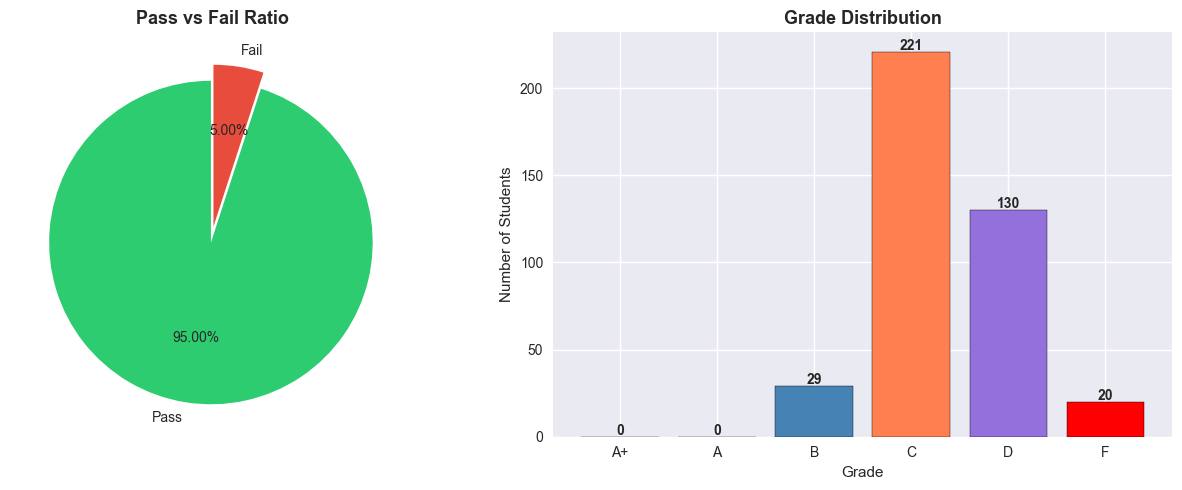

In [4]:
# Graph 2 - Pass vs Fail Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
pass_counts = df['pass_fail'].value_counts()
axes[0].pie(pass_counts,
            labels=pass_counts.index,
            autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Pass vs Fail Ratio', fontsize=13, fontweight='bold')

# Bar chart beside it
grade_order  = ['A+', 'A', 'B', 'C', 'D', 'F']
grade_counts = df['grade'].value_counts().reindex(grade_order, fill_value=0)
axes[1].bar(grade_counts.index, grade_counts.values,
            color=['gold','limegreen','steelblue',
                   'coral','mediumpurple','red'],
            edgecolor='black')
axes[1].set_title('Grade Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Number of Students')

# Add value labels on bars
for i, v in enumerate(grade_counts.values):
    axes[1].text(i, v + 1, str(v),
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/nb_pass_grade.png')
plt.show()

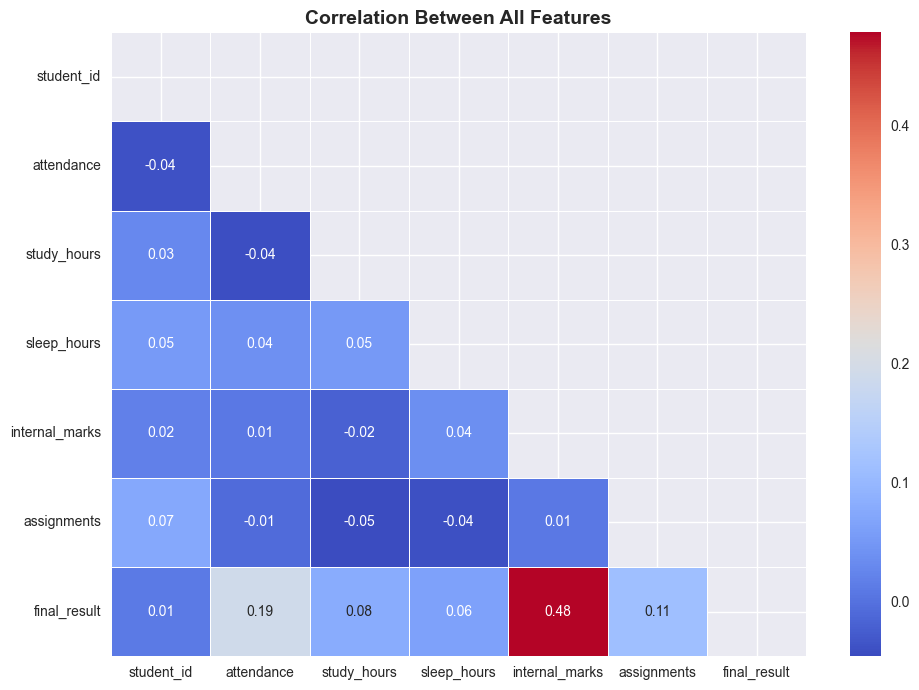

💡 Values closer to 1.0 or -1.0 = strong relationship
💡 Values closer to 0.0 = weak relationship


In [5]:
# Graph 3 - Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            mask=mask)
plt.title('Correlation Between All Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nb_correlation_heatmap.png')
plt.show()
print("💡 Values closer to 1.0 or -1.0 = strong relationship")
print("💡 Values closer to 0.0 = weak relationship")

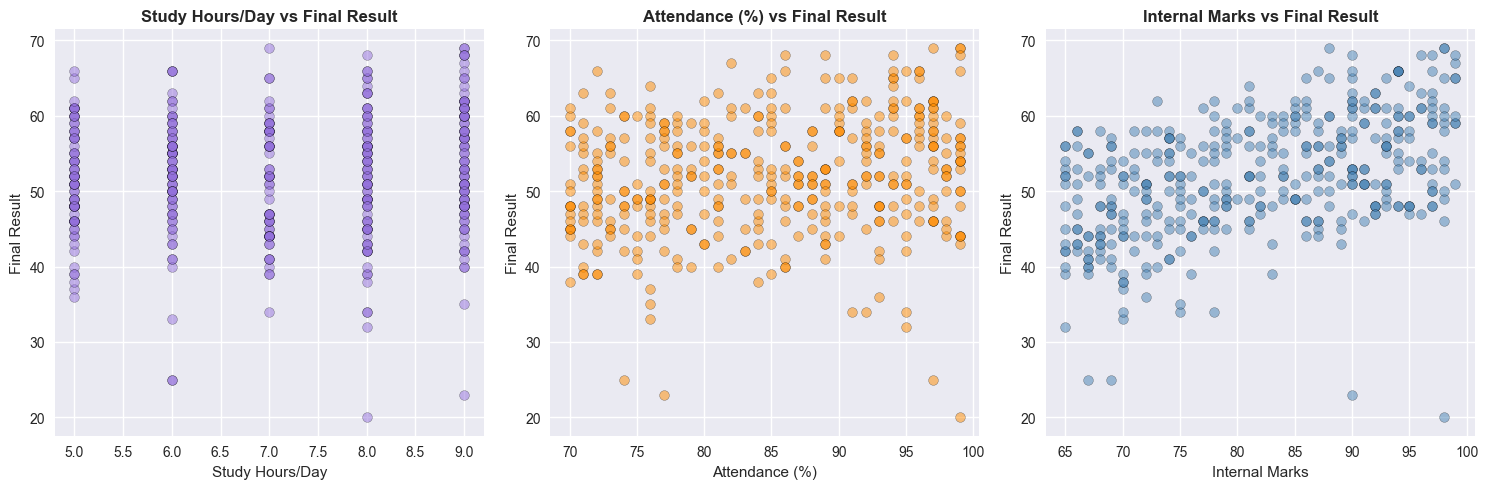

In [6]:
# Graph 4 - Key Feature vs Final Result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_features = [
    ('study_hours',     'Study Hours/Day',  'mediumpurple'),
    ('attendance',      'Attendance (%)',    'darkorange'),
    ('internal_marks',  'Internal Marks',   'steelblue'),
]

for ax, (feature, label, color) in zip(axes, scatter_features):
    ax.scatter(df[feature], df['final_result'],
               alpha=0.5, color=color, edgecolors='black', linewidth=0.3)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Final Result', fontsize=11)
    ax.set_title(f'{label} vs Final Result',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/nb_scatter_plots.png')
plt.show()

---
## 🤖 Step 5 — Machine Learning Models

### What is Train/Test Split?
- We take **80%** of student data to **teach** the model
- We take **20%** of student data to **test** the model
- This way we check if the model works on data it has never seen before

### Models Used:
1. **Linear Regression** — Draws a straight line through data to predict results
2. **Random Forest** — Uses 100 decision trees and takes average of all predictions

In [7]:
# Prepare features and target
features = ['attendance', 'study_hours', 'sleep_hours',
            'internal_marks', 'assignments']
target   = 'final_result'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Training samples : {len(X_train)}")
print(f"✅ Testing samples  : {len(X_test)}")
print(f"✅ Features used    : {features}")# Prepare features and target
features = ['attendance', 'study_hours', 'sleep_hours',
            'internal_marks', 'assignments']
target   = 'final_result'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Training samples : {len(X_train)}")
print(f"✅ Testing samples  : {len(X_test)}")
print(f"✅ Features used    : {features}")

✅ Training samples : 320
✅ Testing samples  : 80
✅ Features used    : ['attendance', 'study_hours', 'sleep_hours', 'internal_marks', 'assignments']
✅ Training samples : 320
✅ Testing samples  : 80
✅ Features used    : ['attendance', 'study_hours', 'sleep_hours', 'internal_marks', 'assignments']


In [8]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred  = lr_model.predict(X_test_scaled)

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_pred  = rf_model.predict(X_test_scaled)

print("✅ Both models trained successfully!")

✅ Both models trained successfully!


In [9]:
# Compare both models in a nice table
results = pd.DataFrame({
    'Metric'           : ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [
        round(mean_absolute_error(y_test, lr_pred), 2),
        round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2),
        round(r2_score(y_test, lr_pred), 4)
    ],
    'Random Forest'    : [
        round(mean_absolute_error(y_test, rf_pred), 2),
        round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2),
        round(r2_score(y_test, rf_pred), 4)
    ]
})

print("=" * 50)
print("      MODEL COMPARISON RESULTS")
print("=" * 50)
print(results.to_string(index=False))
print("=" * 50)

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

if rf_r2 > lr_r2:
    print("\n🏆 Winner: Random Forest performs better!")
else:
    print("\n🏆 Winner: Linear Regression performs better!")

      MODEL COMPARISON RESULTS
  Metric  Linear Regression  Random Forest
     MAE             5.6600         6.0000
    RMSE             7.3500         7.8500
R² Score             0.2727         0.1715

🏆 Winner: Linear Regression performs better!


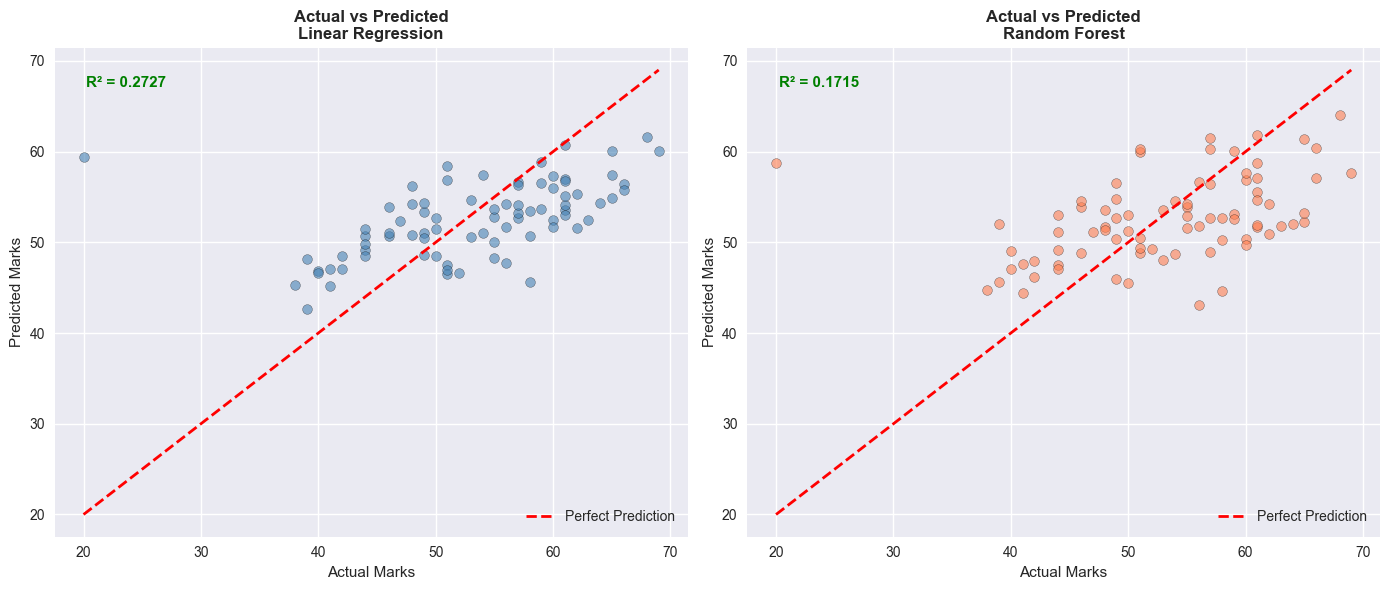

In [10]:
# Actual vs Predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, color, name in zip(
    axes,
    [lr_pred, rf_pred],
    ['steelblue', 'coral'],
    ['Linear Regression', 'Random Forest']
):
    ax.scatter(y_test, pred, alpha=0.6,
               color=color, edgecolors='black', linewidth=0.3)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Marks', fontsize=11)
    ax.set_ylabel('Predicted Marks', fontsize=11)
    ax.set_title(f'Actual vs Predicted\n{name}',
                 fontsize=12, fontweight='bold')
    ax.legend()
    r2 = r2_score(y_test, pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}',
            transform=ax.transAxes,
            fontsize=11, color='green',
            fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/nb_actual_vs_predicted.png')
plt.show()

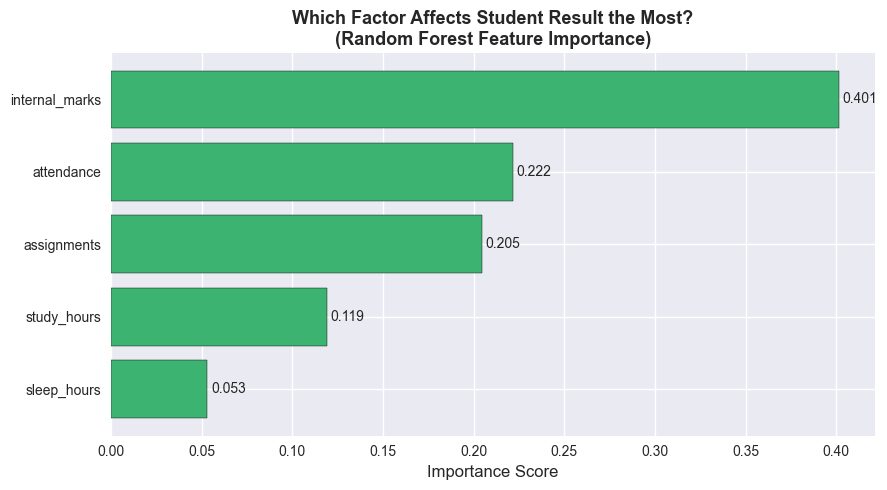

💡 Higher score = more impact on final result


In [11]:
# Feature Importance from Random Forest
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(importance_df['Feature'],
                importance_df['Importance'],
                color='mediumseagreen', edgecolor='black')

for bar, val in zip(bars, importance_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Which Factor Affects Student Result the Most?\n(Random Forest Feature Importance)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/nb_feature_importance.png')
plt.show()
print("💡 Higher score = more impact on final result")

In [12]:
## 🔮 Step 6 — Make a Prediction

# Load saved model and scaler
with open('../models/random_forest.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Sample student data
sample_student = {
    'attendance'    : 85,   # 85% attendance
    'study_hours'   : 7,    # 7 hours/day
    'sleep_hours'   : 7,    # 7 hours sleep
    'internal_marks': 78,   # 78 out of 100
    'assignments'   : 82,   # 82 out of 100
}

print("=" * 40)
print("     SAMPLE STUDENT DETAILS")
print("=" * 40)
for key, val in sample_student.items():
    print(f"  {key:<20}: {val}")

# Scale and predict
input_data  = np.array(list(sample_student.values())).reshape(1, -1)
input_scaled = loaded_scaler.transform(input_data)
prediction  = loaded_model.predict(input_scaled)[0]

# Grade logic
def get_grade(score):
    if score >= 85: return 'A+'
    elif score >= 75: return 'A'
    elif score >= 63: return 'B'
    elif score >= 50: return 'C'
    elif score >= 40: return 'D'
    else: return 'F'

grade  = get_grade(prediction)
status = 'Pass ✅' if prediction >= 40 else 'Fail ❌'

print("=" * 40)
print(f"  Predicted Score : {prediction:.2f} / 100")
print(f"  Grade           : {grade}")
print(f"  Status          : {status}")
print("=" * 40)

     SAMPLE STUDENT DETAILS
  attendance          : 85
  study_hours         : 7
  sleep_hours         : 7
  internal_marks      : 78
  assignments         : 82
  Predicted Score : 47.51 / 100
  Grade           : D
  Status          : Pass ✅


---
## ✅ Step 7 — Conclusion

### Key Findings:
- **Internal Marks** and **Attendance** are the strongest
  predictors of a student's final result
- **Random Forest** outperforms Linear Regression
  with a higher R² Score
- Students with **study hours > 6** tend to score above 75
- Students with **attendance < 60%** are at high risk of failing

### What We Learned:
- How to create and clean a dataset using Pandas
- How to visualize data using Matplotlib and Seaborn
- How to train ML models using Scikit-learn
- How to evaluate and compare multiple ML models
- How to make real predictions using a saved model

### Tech Stack Used:
| Library | Purpose |
|---------|---------|
| Pandas | Data loading and manipulation |
| NumPy | Numerical computations |
| Matplotlib | Data visualization |
| Seaborn | Advanced visualizations |
| Scikit-learn | Machine Learning models |
| Pickle | Saving and loading models |